In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from pd_compute_decodability import process_run
from pd_message_decodability import process_run as process_message_run

RUN_DIRS = [
    REPO_ROOT / "data" / "pass_decision_h256_n0.05_seed0_id2607210153",
    REPO_ROOT / "data" / "pass_decision_seed42_h512_n0.1_id2607141839",
]

H5_NAME = "gaussian.h5"  # continuous activity; data.h5 is pre-poissonified
SEED = 0
AREAS = ["P", "D"]
TARGET_ORDER = ["inp", "cumsum", "sign_cumsum"]

METRIC_LABELS = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

for run_dir in RUN_DIRS:
    h5 = run_dir / H5_NAME
    if not h5.is_file():
        raise FileNotFoundError(f"Missing {h5}")


In [2]:
rows = []
for run_dir in RUN_DIRS:
    print(f"Computing: {run_dir.name} ({H5_NAME})")
    rows.extend(process_run(run_dir, areas=AREAS, seed=SEED, h5_name=H5_NAME))

df = pd.DataFrame(rows)
df


Computing: pass_decision_h256_n0.05_seed0_id2607210153 (gaussian.h5)
    [P] continuous → inp           R2=+0.9977   (  3.7s)
    [P] continuous → cumsum        R2=+0.0426   (  3.4s)
    [P] continuous → sign_cumsum   R2=+0.0470   (  3.5s)
    [P] poisson  dt=0.01 rate= 20 → inp           R2=+0.1331   (sample  1.8s + decode  3.6s)
    [P] poisson  dt=0.01 rate= 20 → cumsum        R2=-0.0107   (sample  1.8s + decode  3.4s)
    [P] poisson  dt=0.01 rate= 20 → sign_cumsum   R2=-0.0031   (sample  1.8s + decode  3.5s)
    [P] poisson  dt=0.01 rate= 40 → inp           R2=+0.2341   (sample  1.9s + decode  3.3s)
    [P] poisson  dt=0.01 rate= 40 → cumsum        R2=-0.0092   (sample  1.9s + decode  3.2s)
    [P] poisson  dt=0.01 rate= 40 → sign_cumsum   R2=-0.0014   (sample  1.9s + decode  3.3s)
    [P] poisson  dt=0.05 rate= 40 → inp           R2=+0.6079   (sample  2.6s + decode  4.1s)
    [P] poisson  dt=0.05 rate= 40 → cumsum        R2=-0.0015   (sample  2.6s + decode  3.2s)
    [P] poisson 

,run_name,decode_from,target,hidden_size,noise_p,noise_d,ws,swept,score_continuous,score_poisson_dt0.01_rate20,score_poisson_dt0.01_rate40,score_poisson_dt0.05_rate40
0,pass_decision_h256_n0.05_seed0_id2607210153,P,inp,256,0.05,0.05,1.0,noise,0.997723,0.133116,0.234071,0.607922
1,pass_decision_h256_n0.05_seed0_id2607210153,P,cumsum,256,0.05,0.05,1.0,noise,0.042593,-0.010651,-0.009154,-0.001501
2,pass_decision_h256_n0.05_seed0_id2607210153,P,sign_cumsum,256,0.05,0.05,1.0,noise,0.046954,-0.003122,-0.001445,0.003201
3,pass_decision_h256_n0.05_seed0_id2607210153,D,inp,256,0.05,0.05,1.0,noise,0.968076,0.077692,0.138523,0.392573
4,pass_decision_h256_n0.05_seed0_id2607210153,D,cumsum,256,0.05,0.05,1.0,noise,0.926936,0.636054,0.743986,0.863401
5,pass_decision_h256_n0.05_seed0_id2607210153,D,sign_cumsum,256,0.05,0.05,1.0,noise,0.831440,0.505351,0.592124,0.692330
6,pass_decision_seed42_h512_n0.1_id2607141839,P,inp,512,0.10,0.10,1.0,noise,0.994832,0.161628,0.265414,0.674392
7,pass_decision_seed42_h512_n0.1_id2607141839,P,cumsum,512,0.10,0.10,1.0,noise,0.076977,-0.002701,0.000835,0.017022
8,pass_decision_seed42_h512_n0.1_id2607141839,P,sign_cumsum,512,0.10,0.10,1.0,noise,0.080475,-0.001473,0.002970,0.021274
9,pass_decision_seed42_h512_n0.1_id2607141839,D,inp,512,0.10,0.10,1.0,noise,0.899106,0.160922,0.252285,0.525078


In [3]:
score_cols = [c for c in df.columns if c.startswith("score_")]
key_cols = ["decode_from", "target"]
run_a, run_b = [d.name for d in RUN_DIRS]

compare_rows = []
for metric in score_cols:
    sub = df.pivot(index=key_cols, columns="run_name", values=metric)
    block = sub.reset_index()
    block.insert(0, "metric", metric)
    block[f"Δ ({run_a} − {run_b})"] = block[run_a] - block[run_b]
    compare_rows.append(block)

compare = pd.concat(compare_rows, ignore_index=True)
compare.round(4)


run_name,metric,decode_from,target,pass_decision_h256_n0.05_seed0_id2607210153,pass_decision_seed42_h512_n0.1_id2607141839,Δ (pass_decision_h256_n0.05_seed0_id2607210153 − pass_decision_seed42_h512_n0.1_id2607141839)
0,score_continuous,D,cumsum,0.9269,0.9126,0.0143
1,score_continuous,D,inp,0.9681,0.8991,0.0690
2,score_continuous,D,sign_cumsum,0.8314,0.8402,-0.0088
3,score_continuous,P,cumsum,0.0426,0.0770,-0.0344
4,score_continuous,P,inp,0.9977,0.9948,0.0029
5,score_continuous,P,sign_cumsum,0.0470,0.0805,-0.0335
6,score_poisson_dt0.01_rate20,D,cumsum,0.6361,0.6670,-0.0310
7,score_poisson_dt0.01_rate20,D,inp,0.0777,0.1609,-0.0832
8,score_poisson_dt0.01_rate20,D,sign_cumsum,0.5054,0.6374,-0.1320
9,score_poisson_dt0.01_rate20,P,cumsum,-0.0107,-0.0027,-0.0080


In [2]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

score_cols = [c for c in df.columns if c.startswith("score_")]
metric_colors = {m: f"C{i}" for i, m in enumerate(score_cols)}
area_hatch = {"P": "", "D": "///"}


def plot_run_bars(run_df: pd.DataFrame, run_name: str, ax: plt.Axes) -> None:
    n_metrics = len(score_cols)
    n_areas = len(AREAS)
    bar_width = 0.09
    group_gap = 0.35
    x = np.arange(len(TARGET_ORDER)) * (n_metrics * n_areas * bar_width + group_gap)

    for mi, metric in enumerate(score_cols):
        for ai, area in enumerate(AREAS):
            vals = [
                run_df[
                    (run_df["decode_from"] == area) & (run_df["target"] == target)
                ][metric].iloc[0]
                for target in TARGET_ORDER
            ]
            offset = mi * n_areas * bar_width + ai * bar_width
            ax.bar(
                x + offset,
                vals,
                width=bar_width,
                color=metric_colors[metric],
                hatch=area_hatch[area],
                edgecolor="black",
                linewidth=0.6,
            )

    ax.set_xticks(x + (n_metrics * n_areas * bar_width - bar_width) / 2)
    ax.set_xticklabels(TARGET_ORDER)
    ax.set_xlabel("target")
    ax.set_ylabel(r"$R^2$")
    ax.set_title(run_name, fontsize=10)
    ax.axhline(0, color="0.5", linewidth=0.8)
    ax.set_ylim(-0.15, 1.05)


fig, axes = plt.subplots(1, len(RUN_DIRS), figsize=(7 * len(RUN_DIRS), 5), sharey=True)
if len(RUN_DIRS) == 1:
    axes = [axes]

for ax, run_dir in zip(axes, RUN_DIRS):
    run_df = df[df["run_name"] == run_dir.name]
    plot_run_bars(run_df, run_dir.name, ax)

metric_handles = [
    Patch(facecolor=metric_colors[m], edgecolor="black", label=METRIC_LABELS[m])
    for m in score_cols
]
area_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=area_hatch[a], label=f"decode from {a}")
    for a in AREAS
]
fig.legend(
    handles=metric_handles + area_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(score_cols) + len(AREAS),
    frameon=False,
)
fig.suptitle(f"Decodability from {H5_NAME}", y=1.08)
fig.tight_layout()
plt.show()


NameError: name 'df' is not defined

## Message decodability (`message-p_to_d`)

Decode the P→D message from area-P (sender) vs area-D (receiver) hidden activity.

In [ ]:
msg_rows = []
for run_dir in RUN_DIRS:
    print(f"Message decodability: {run_dir.name} ({H5_NAME})")
    msg_rows.extend(process_message_run(run_dir, seed=SEED, h5_name=H5_NAME))

msg_df = pd.DataFrame(msg_rows)
msg_df

In [ ]:
REP_ORDER = [
    "continuous",
    "poisson_dt0.01_rate20",
    "poisson_dt0.01_rate40",
    "poisson_dt0.05_rate40",
]
REP_LABELS = {
    "continuous": "Continuous",
    "poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

run_a, run_b = [d.name for d in RUN_DIRS]
score_cols = ["r2_P", "r2_D", "diff", "selectivity"]

msg_compare_rows = []
for metric in score_cols:
    sub = msg_df.pivot(index="representation", columns="run_name", values=metric)
    block = sub.reset_index()
    block.insert(0, "metric", metric)
    block[f"Δ ({run_a} − {run_b})"] = block[run_a] - block[run_b]
    msg_compare_rows.append(block)

msg_compare = pd.concat(msg_compare_rows, ignore_index=True)
msg_compare.round(4)

In [ ]:
area_colors = {"r2_P": "C0", "r2_D": "C1"}


def plot_message_bars(run_df: pd.DataFrame, run_name: str, ax: plt.Axes) -> None:
    bar_width = 0.35
    x = np.arange(len(REP_ORDER))

    for ai, col in enumerate(["r2_P", "r2_D"]):
        vals = [
            run_df[run_df["representation"] == rep][col].iloc[0]
            for rep in REP_ORDER
        ]
        offset = (ai - 0.5) * bar_width
        ax.bar(
            x + offset,
            vals,
            width=bar_width,
            color=area_colors[col],
            edgecolor="black",
            linewidth=0.6,
            label=col,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([REP_LABELS[r] for r in REP_ORDER], rotation=20, ha="right")
    ax.set_ylabel(r"$R^2$")
    ax.set_title(run_name, fontsize=10)
    ax.axhline(0, color="0.5", linewidth=0.8)
    ax.set_ylim(-0.15, 1.05)


fig, axes = plt.subplots(1, len(RUN_DIRS), figsize=(7 * len(RUN_DIRS), 5), sharey=True)
if len(RUN_DIRS) == 1:
    axes = [axes]

for ax, run_dir in zip(axes, RUN_DIRS):
    run_df = msg_df[msg_df["run_name"] == run_dir.name]
    plot_message_bars(run_df, run_dir.name, ax)

handles = [
    Patch(facecolor=area_colors[c], edgecolor="black", label=c)
    for c in ["r2_P", "r2_D"]
]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
fig.suptitle(f"message-p_to_d decodability from {H5_NAME}", y=1.08)
fig.tight_layout()
plt.show()

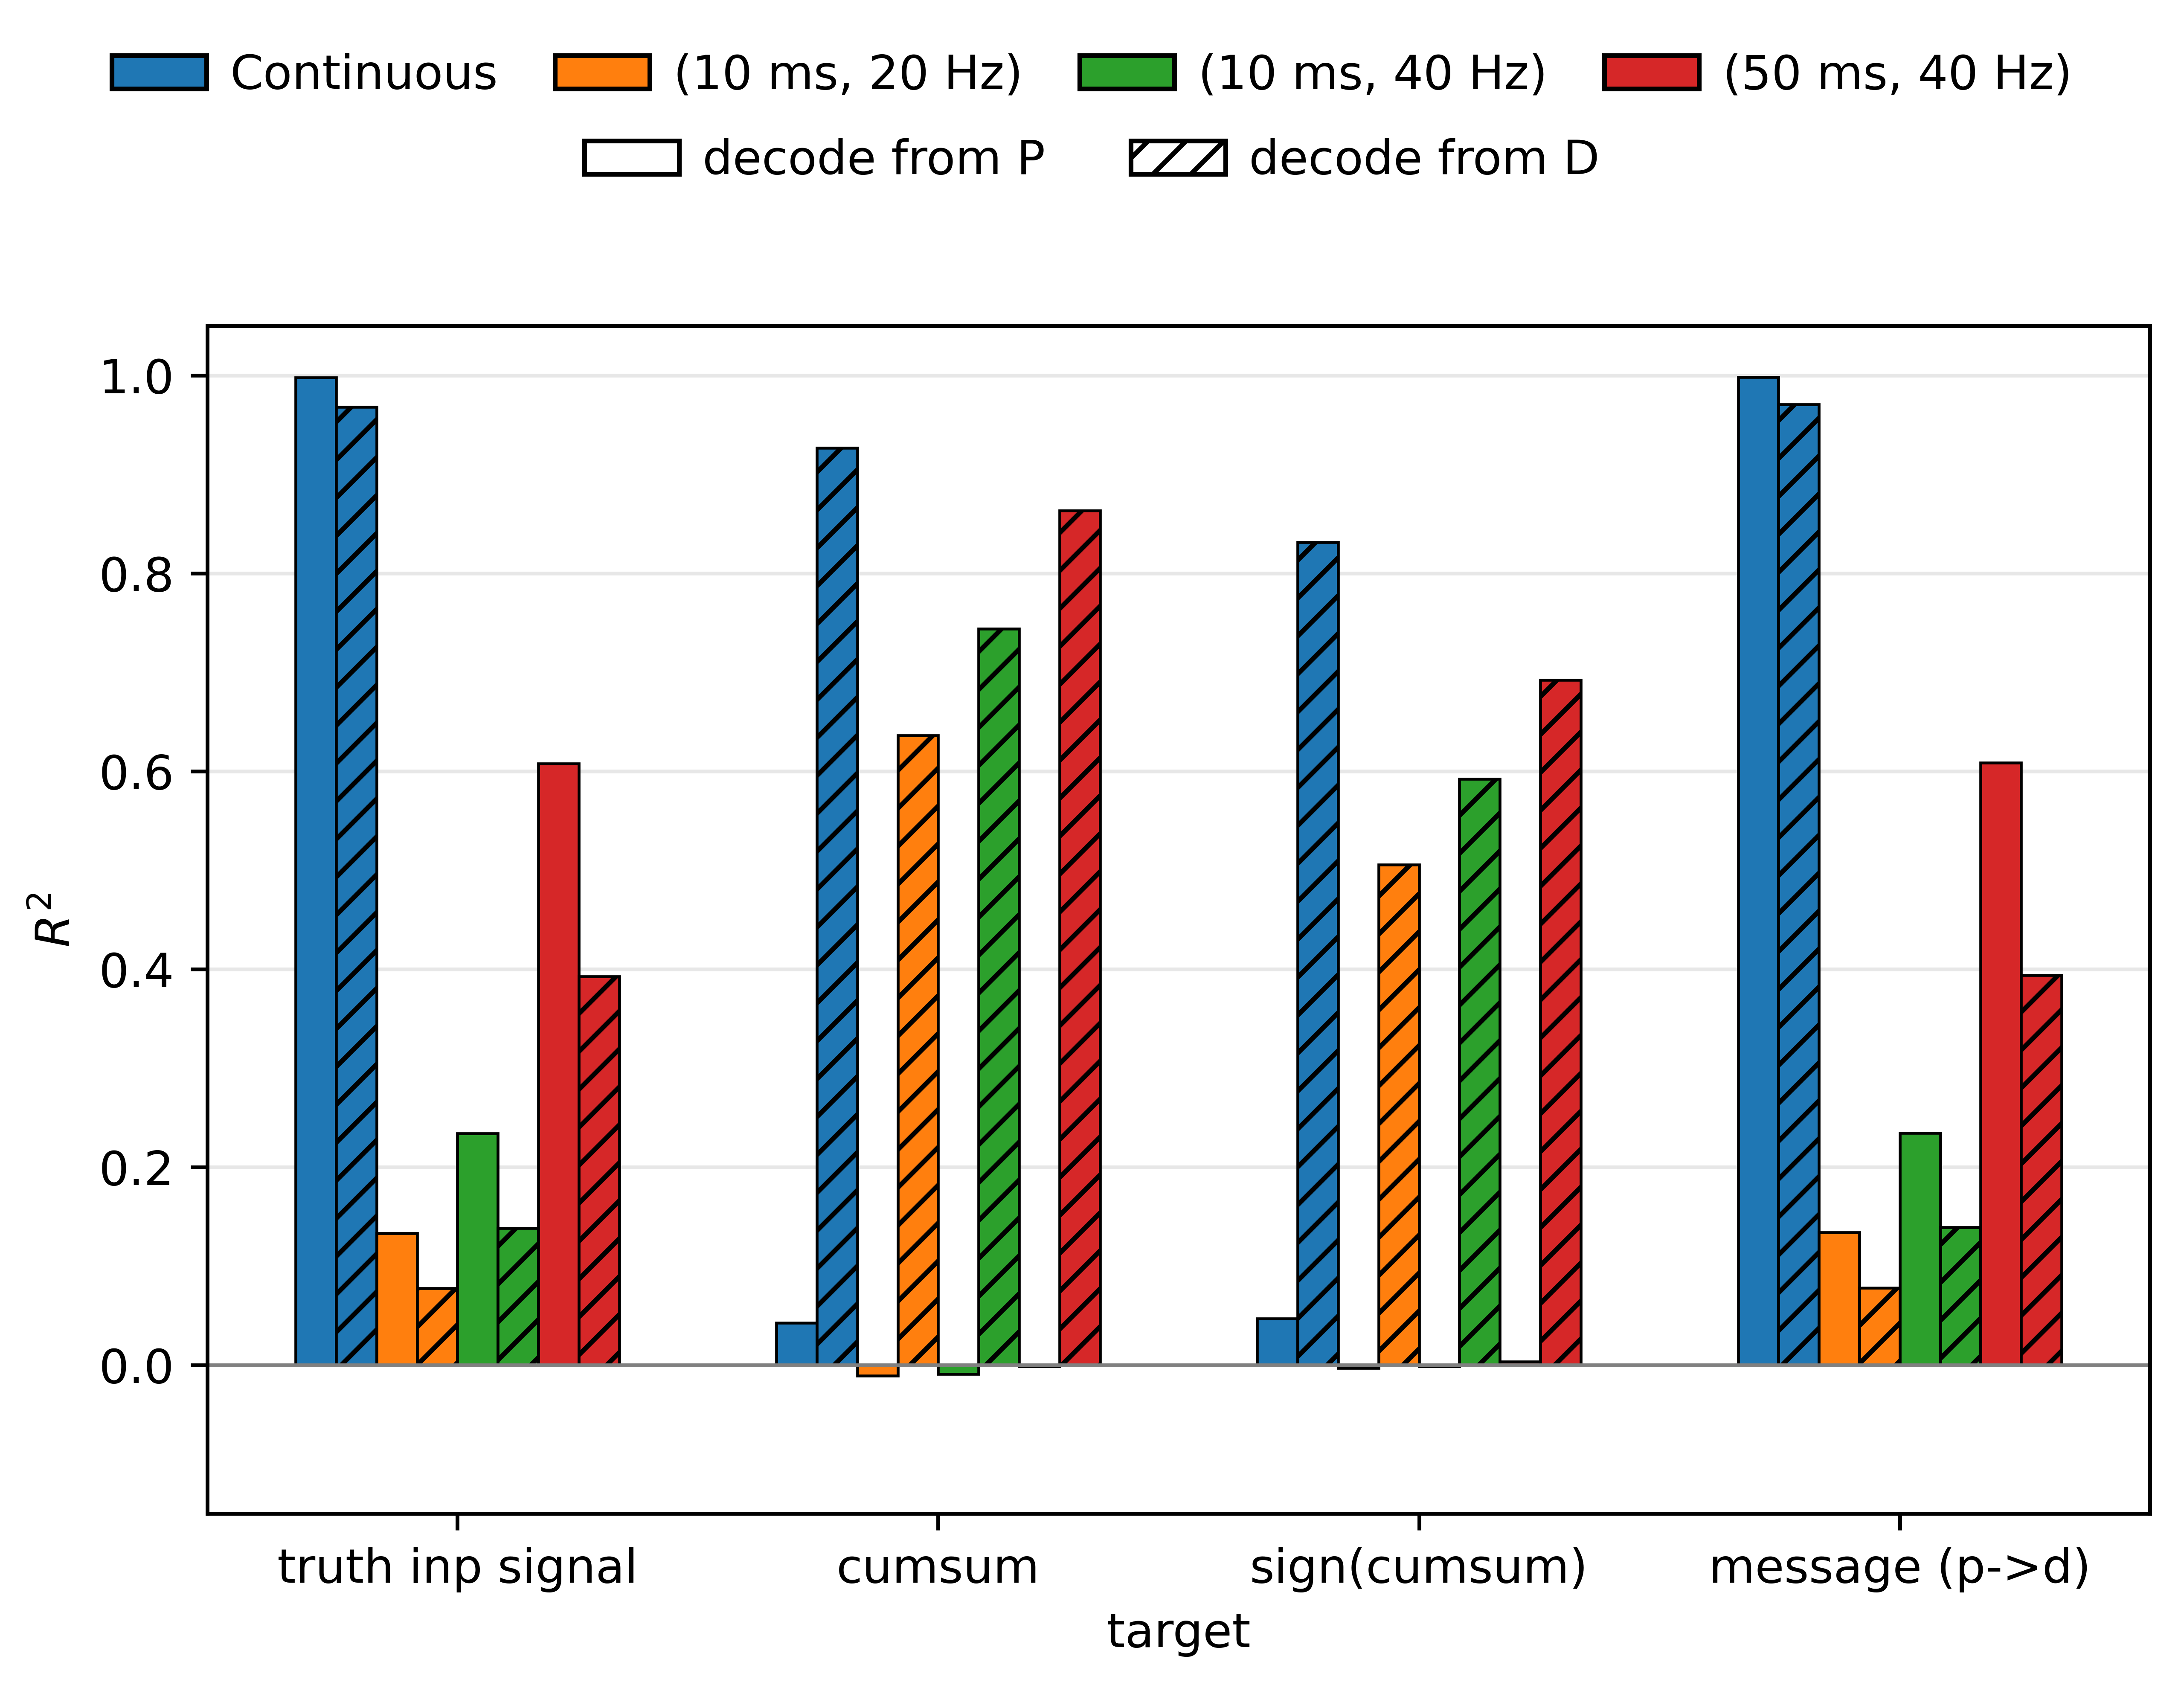

In [4]:
# 256-only visualization with hardcoded values (single combined plot)
from matplotlib.patches import Patch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

run_256 = "pass_decision_h256_n0.05_seed0_id2607210153"

TARGET_ORDER = ["inp", "cumsum", "sign_cumsum", "message"]
AREAS = ["P", "D"]
score_cols = [
    "score_continuous",
    "score_poisson_dt0.01_rate20",
    "score_poisson_dt0.01_rate40",
    "score_poisson_dt0.05_rate40",
]
METRIC_LABELS = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "(10 ms, 20 Hz)",
    "score_poisson_dt0.01_rate40": "(10 ms, 40 Hz)",
    "score_poisson_dt0.05_rate40": "(50 ms, 40 Hz)",
}
metric_to_rep = {
    "score_continuous": "continuous",
    "score_poisson_dt0.01_rate20": "poisson_dt0.01_rate20",
    "score_poisson_dt0.01_rate40": "poisson_dt0.01_rate40",
    "score_poisson_dt0.05_rate40": "poisson_dt0.05_rate40",
}

# Hardcoded area->target decodability for 256 run (from provided output)
area_target_values = {
    ("P", "inp"): {
        "score_continuous": 0.9977,
        "score_poisson_dt0.01_rate20": 0.1331,
        "score_poisson_dt0.01_rate40": 0.2341,
        "score_poisson_dt0.05_rate40": 0.6079,
    },
    ("P", "cumsum"): {
        "score_continuous": 0.0426,
        "score_poisson_dt0.01_rate20": -0.0107,
        "score_poisson_dt0.01_rate40": -0.0092,
        "score_poisson_dt0.05_rate40": -0.0015,
    },
    ("P", "sign_cumsum"): {
        "score_continuous": 0.0470,
        "score_poisson_dt0.01_rate20": -0.0031,
        "score_poisson_dt0.01_rate40": -0.0014,
        "score_poisson_dt0.05_rate40": 0.0032,
    },
    ("D", "inp"): {
        "score_continuous": 0.9681,
        "score_poisson_dt0.01_rate20": 0.0777,
        "score_poisson_dt0.01_rate40": 0.1385,
        "score_poisson_dt0.05_rate40": 0.3926,
    },
    ("D", "cumsum"): {
        "score_continuous": 0.9269,
        "score_poisson_dt0.01_rate20": 0.6361,
        "score_poisson_dt0.01_rate40": 0.7440,
        "score_poisson_dt0.05_rate40": 0.8634,
    },
    ("D", "sign_cumsum"): {
        "score_continuous": 0.8314,
        "score_poisson_dt0.01_rate20": 0.5054,
        "score_poisson_dt0.01_rate40": 0.5921,
        "score_poisson_dt0.05_rate40": 0.6923,
    },
}

# Hardcoded message-p_to_d decodability for 256 run (from computed output)
message_values = {
    "continuous": {"P": 0.9984, "D": 0.9707},
    "poisson_dt0.01_rate20": {"P": 0.1340, "D": 0.0781},
    "poisson_dt0.01_rate40": {"P": 0.2345, "D": 0.1391},
    "poisson_dt0.05_rate40": {"P": 0.6085, "D": 0.3939},
}


def get_value(area: str, target: str, metric: str) -> float:
    if target == "message":
        rep = metric_to_rep[metric]
        return message_values[rep][area]
    return area_target_values[(area, target)][metric]



metric_colors = {m: f"C{i}" for i, m in enumerate(score_cols)}
area_hatch = {"P": "", "D": "///"}

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=800)
n_metrics = len(score_cols)
n_areas = len(AREAS)
bar_width = 0.09
group_gap = 0.35
x = np.arange(len(TARGET_ORDER)) * (n_metrics * n_areas * bar_width + group_gap)

for mi, metric in enumerate(score_cols):
    for ai, area in enumerate(AREAS):
        vals = [get_value(area, target, metric) for target in TARGET_ORDER]
        offset = mi * n_areas * bar_width + ai * bar_width
        ax.bar(
            x + offset,
            vals,
            width=bar_width,
            color=metric_colors[metric],
            hatch=area_hatch[area],
            edgecolor="black",
            linewidth=0.6,
        )

ax.set_xticks(x + (n_metrics * n_areas * bar_width - bar_width) / 2)
ax.set_xticklabels(["truth inp signal", "cumsum", "sign(cumsum)", "message (p->d)"])
ax.set_xlabel("target")
ax.set_ylabel(r"$R^2$")
# ax.set_title(f"{run_256}\narea decodability (hardcoded)", fontsize=10)
ax.axhline(0, color="0.5", linewidth=0.8)
ax.set_ylim(-0.15, 1.05)

ax.grid(axis="y", alpha=0.3)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

metric_handles = [
    Patch(facecolor=metric_colors[m], edgecolor="black", label=METRIC_LABELS[m])
    for m in score_cols
]
area_handles = [
    Patch(facecolor="white", edgecolor="black",
          hatch=area_hatch[a], label=f"decode from {a}")
    for a in AREAS
]

# Top row: 4 metric entries
leg1 = fig.legend(
    handles=metric_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=4,
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.5,
)

# Second row: 2 area entries
leg2 = fig.legend(
    handles=area_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=2,
    frameon=False,
    columnspacing=1.8,
    handletextpad=0.5,
)

fig.tight_layout(rect=[0, 0, 1, 0.84])

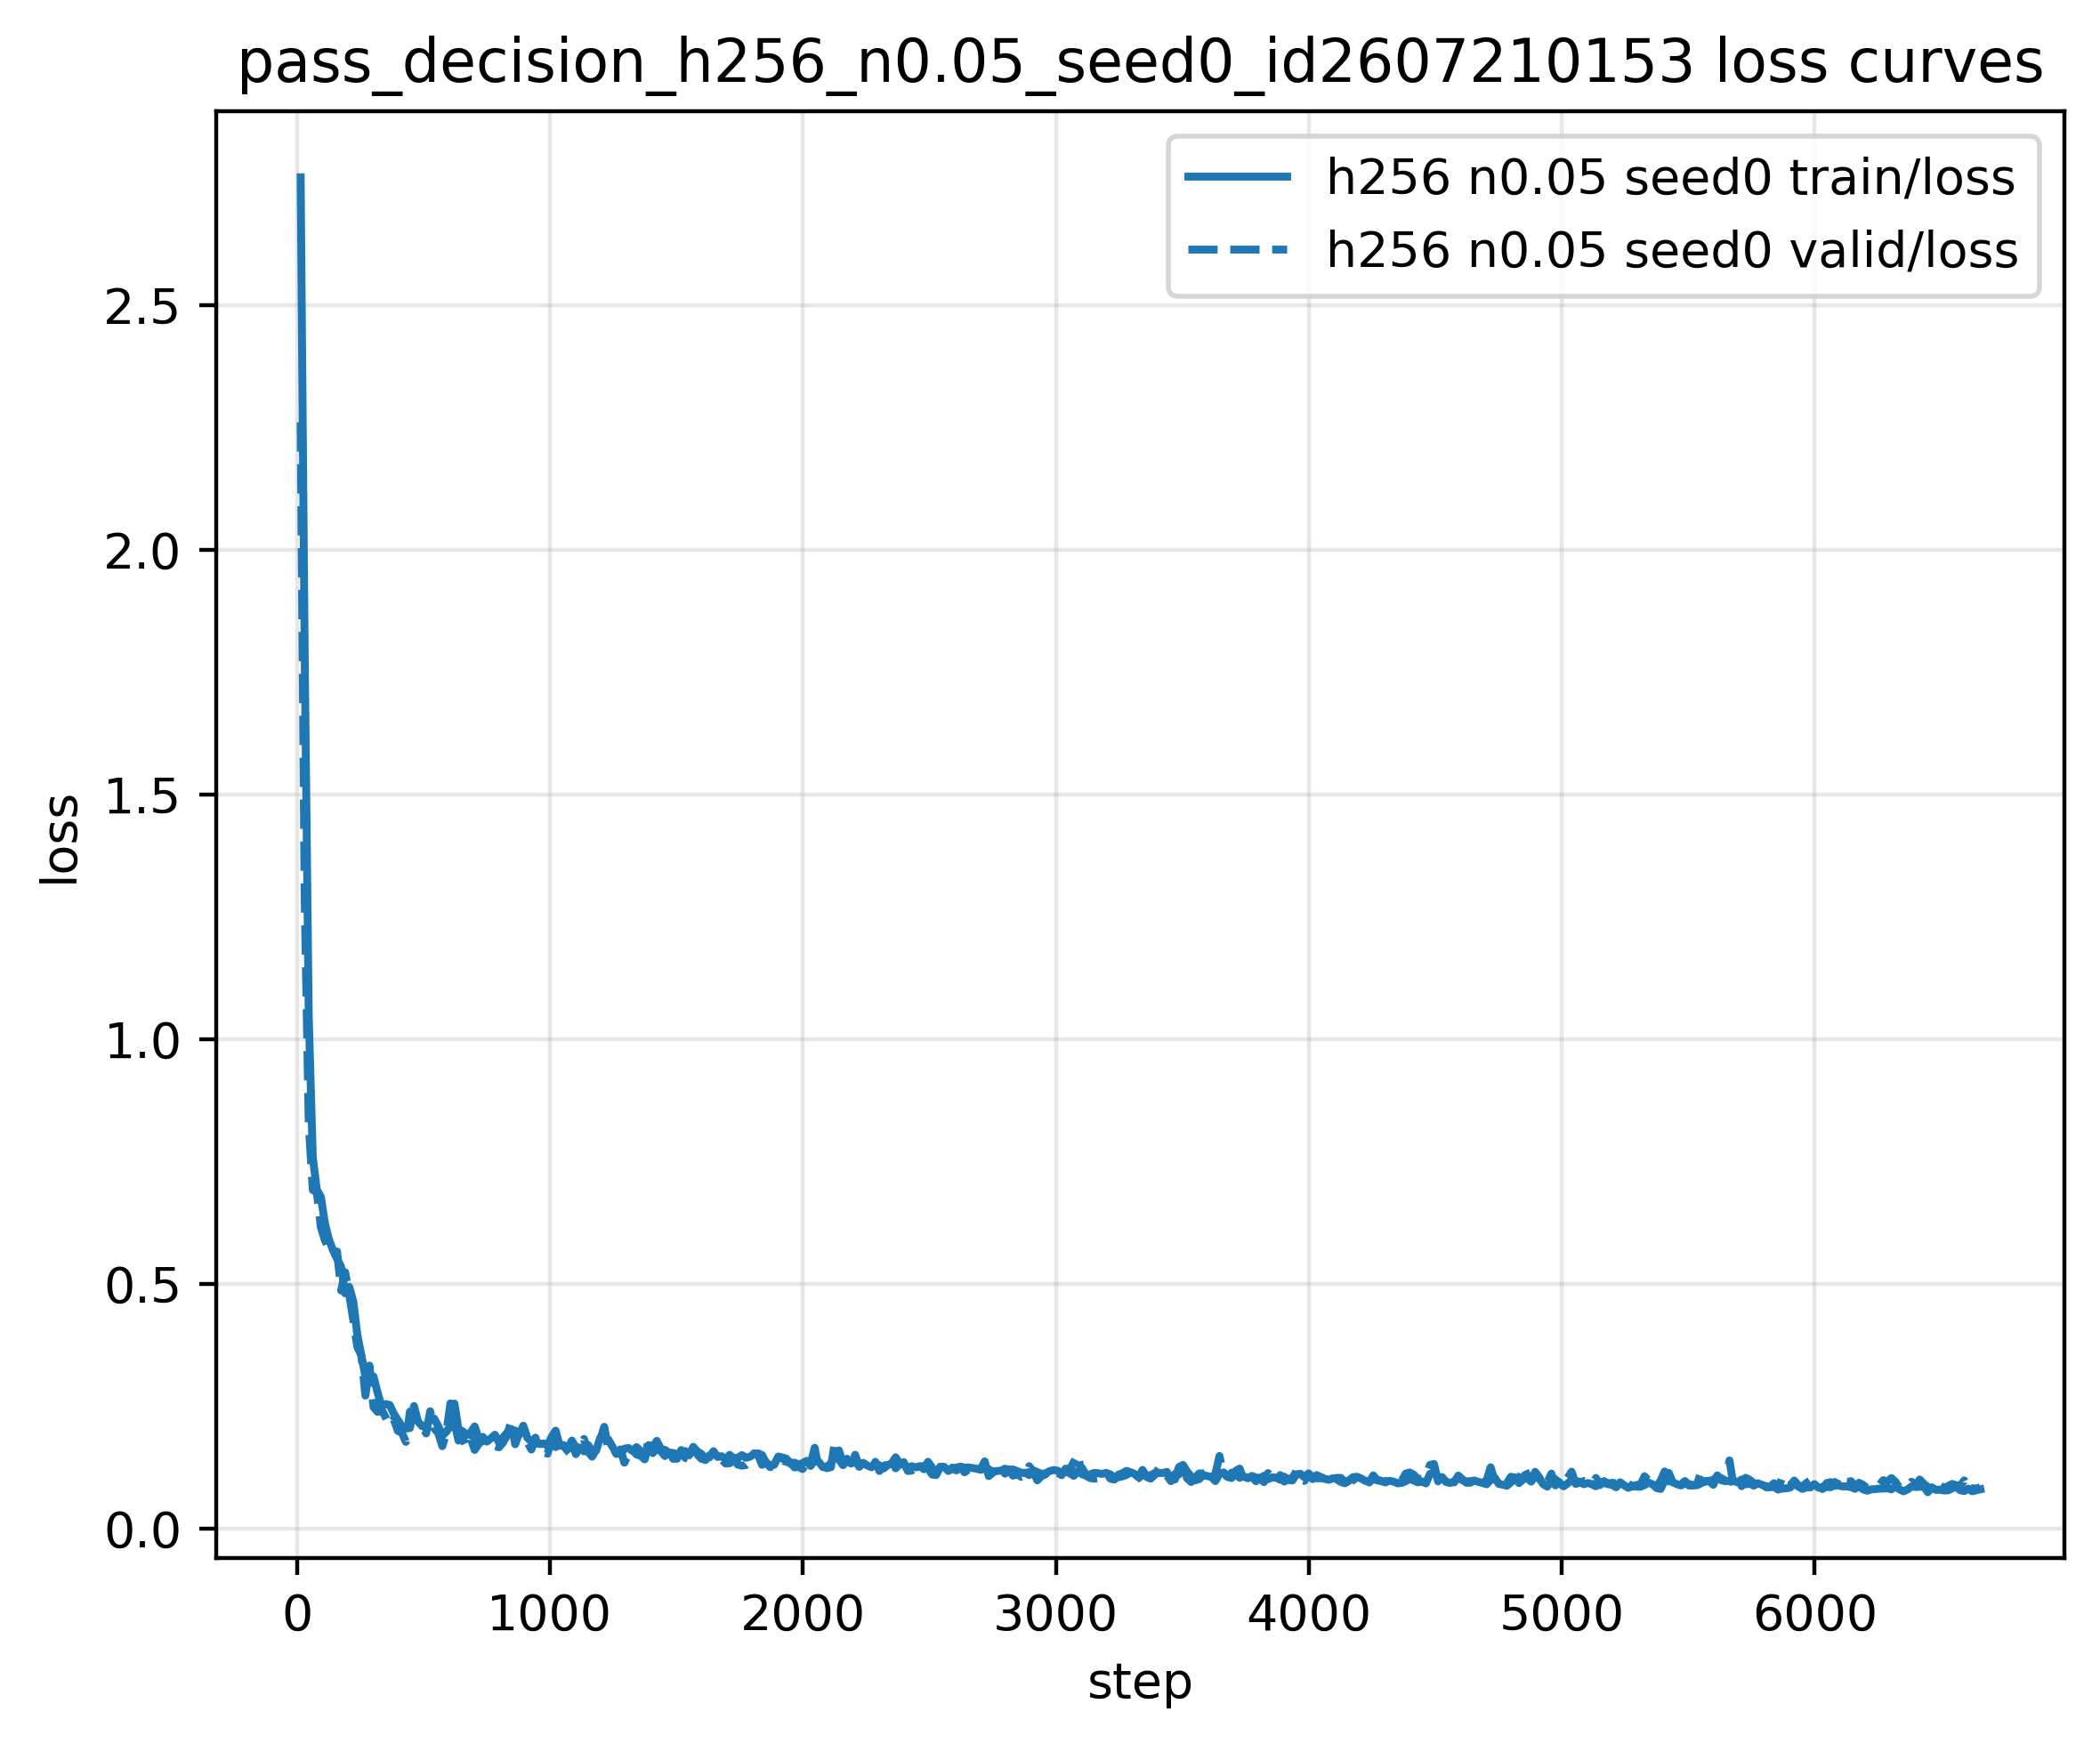

pass_decision_seed42_h512_n0.1_id2607141839: C:\Users\wlo12\OneDrive\Desktop\Projects\dgn\data\pass_decision_seed42_h512_n0.1_id2607141839\events.out.tfevents.1784079704.g3123.69107.0


In [18]:
# Loss curves for 256 and 512 runs (overlaid)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

RUN_NAMES = [
    # "pass_decision_h256_n0.05_seed0_id2607210153",
    "pass_decision_seed42_h512_n0.1_id2607141839",
]
REPO_ROOT = Path("..").resolve()


def candidate_dirs_for(run_name: str) -> list[Path]:
    return [
        REPO_ROOT / "pd_runs" / "noise_runs" / run_name,
        REPO_ROOT / "data" / run_name,
        REPO_ROOT / "pass_decision" / "noise_runs_seed0" / run_name,
    ]


def find_event_file(run_dirs: list[Path]) -> Path:
    for run_dir in run_dirs:
        if not run_dir.exists():
            continue
        files = sorted(run_dir.glob("events.out.tfevents*"))
        if files:
            return files[0]
        # also search recursively (some loggers write nested dirs)
        files_nested = sorted(run_dir.glob("**/events.out.tfevents*"))
        if files_nested:
            return files_nested[0]
    raise FileNotFoundError(
        "No TensorBoard event file found in expected locations:\n"
        + "\n".join(str(p) for p in run_dirs)
    )


def load_scalars(event_file: Path, tag: str) -> pd.DataFrame:
    ea = EventAccumulator(str(event_file), size_guidance={"scalars": 0})
    ea.Reload()
    if tag not in ea.Tags().get("scalars", []):
        return pd.DataFrame(columns=["step", "value", "tag"])
    scalars = ea.Scalars(tag)
    return pd.DataFrame(
        [{"step": s.step, "value": s.value, "tag": tag} for s in scalars]
    )


loaded = {}
for run_name in RUN_NAMES:
    ev = find_event_file(candidate_dirs_for(run_name))
    train_df = load_scalars(ev, "train/loss")
    valid_df = load_scalars(ev, "valid/loss")
    if train_df.empty and valid_df.empty:
        raise ValueError(f"Found event file but no train/loss or valid/loss tags: {ev}")
    loaded[run_name] = {"event": ev, "train": train_df, "valid": valid_df}


fig, ax = plt.subplots(figsize=(6, 5), dpi=400)
run_styles = {
    RUN_NAMES[0]: {"color": "C0", "label": "h256 n0.05 seed0"},
    # RUN_NAMES[1]: {"color": "C1", "label": "h512 n0.1 seed42"},
}

# From config: batch_total=2048, batch_size=64 -> ~32 steps per epoch
STEPS_PER_EPOCH = 1

for run_name, data in loaded.items():
    style = run_styles[run_name]
    if not data["train"].empty:
        train_epochs = data["train"]["step"] / STEPS_PER_EPOCH
        ax.plot(
            train_epochs,
            data["train"]["value"],
            color=style["color"],
            linestyle="-",
            linewidth=1.6,
            label=f"{style['label']} train/loss",
        )
    if not data["valid"].empty:
        valid_epochs = data["valid"]["step"] / STEPS_PER_EPOCH
        ax.plot(
            valid_epochs,
            data["valid"]["value"],
            color=style["color"],
            linestyle="--",
            linewidth=1.6,
            label=f"{style['label']} valid/loss",
        )

ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.grid(alpha=0.3)
ax.legend()
plt.title("pass_decision_h256_n0.05_seed0_id2607210153 loss curves")
plt.tight_layout()
plt.show()

for run_name, data in loaded.items():
    print(f"{run_name}: {data['event']}")